<a href="https://colab.research.google.com/github/Mohanigupta10/Titanic_Passenger_survival/blob/main/Time_Series_Sales_Forcasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv"
df = pd.read_csv(url)

df.head()

,Month,Sales
0,1960-01,6550
1,1960-02,8728
2,1960-03,12026
3,1960-04,14395
4,1960-05,14587


     Month  Sales
0  1960-01   6550
1  1960-02   8728
2  1960-03  12026
3  1960-04  14395
4  1960-05  14587

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 108 entries, 1960-01-01 to 1968-12-01
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Sales   108 non-null    int64
dtypes: int64(1)
memory usage: 1.7 KB
None

Missing Values:
Sales    0
dtype: int64


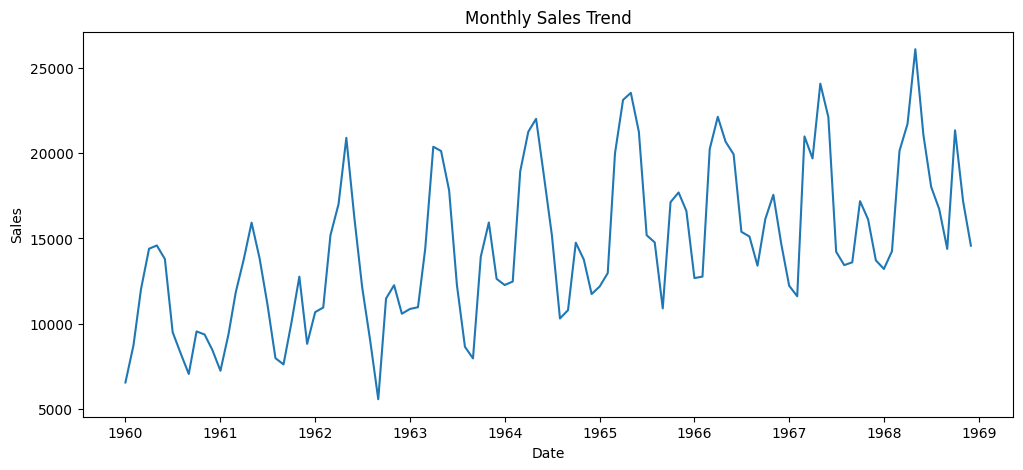

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)



Next 12 Months Forecast:
1969-01-01    15559.731887
1969-02-01    16237.547921
1969-03-01    21761.640550
1969-04-01    23956.376426
1969-05-01    25564.418447
1969-06-01    22960.222098
1969-07-01    18344.326242
1969-08-01    16246.500496
1969-09-01    14805.927655
1969-10-01    19281.800996
1969-11-01    19409.235872
1969-12-01    17099.571811
Freq: MS, dtype: float64


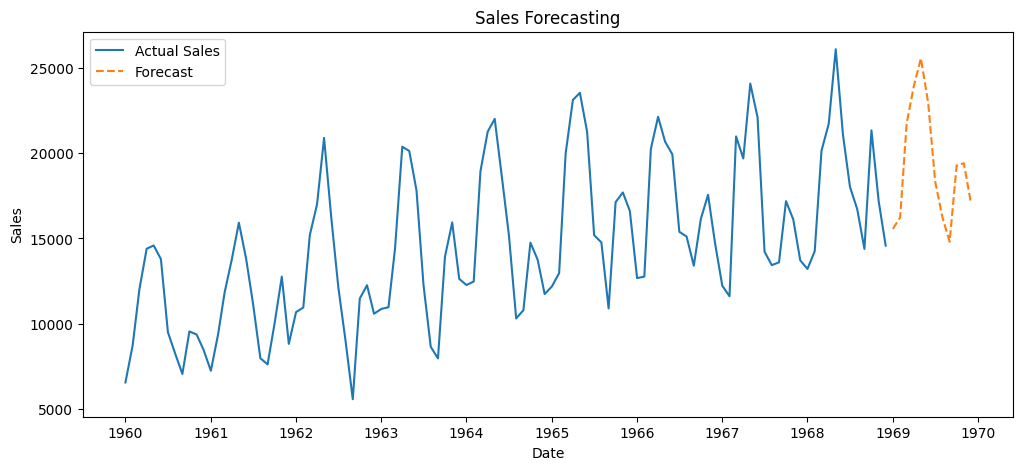


Project Completed Successfully!
forecast_results.csv saved.


In [4]:
# Install library
!pip install statsmodels -q

# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Load dataset directly from URL
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/monthly-car-sales.csv"
df = pd.read_csv(url)

# Display first 5 rows
print(df.head())

# Rename columns
df.columns = ['Month', 'Sales']

# Convert Month to datetime
df['Month'] = pd.to_datetime(df['Month'])

# Set index
df.set_index('Month', inplace=True)

# Dataset Information
print("\nDataset Info:")
print(df.info())

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Plot Sales Trend
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Sales'])
plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

# Train Forecasting Model
model = ExponentialSmoothing(
    df['Sales'],
    trend='add',
    seasonal='add',
    seasonal_periods=12
).fit()

# Forecast Next 12 Months
forecast = model.forecast(12)

# Print Forecast
print("\nNext 12 Months Forecast:")
print(forecast)

# Plot Forecast
plt.figure(figsize=(12,5))
plt.plot(df.index, df['Sales'], label='Actual Sales')
plt.plot(forecast.index, forecast, label='Forecast', linestyle='--')
plt.title("Sales Forecasting")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.show()

# Save Forecast Results
forecast_df = pd.DataFrame({
    'Forecasted Sales': forecast
})

forecast_df.to_csv("forecast_results.csv")

print("\nProject Completed Successfully!")
print("forecast_results.csv saved.")